In [187]:
!pip install torch torchvision torchaudio

In [188]:
# Install common data science and ML packages (like Colab/Kaggle)
%pip install -q numpy pandas matplotlib seaborn scikit-learn scipy \
    torch-geometric networkx plotly tqdm jupyter ipywidgets


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [189]:
!pip install ipykernel


In [190]:
! python --version

Python 3.12.7


In [191]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS (Metal) available: {torch.backends.mps.is_available()}")

PyTorch version: 2.9.1
CUDA available: False
MPS (Metal) available: True


In [192]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

In [193]:
import pandas as pd
import numpy as np
edges_path = '/Users/devanshsharma/github/PathFinder/PathFinder/Learning-Phase/GNN/edges.csv'

df = pd.read_csv(edges_path)
edges=torch.tensor(np.stack((df['id_1'].to_numpy(), df['id_2'].to_numpy()), axis=0) )
edges


tensor([[    0,     1,     1,  ..., 37644, 25879, 25616],
        [23977, 34526,  2370,  ...,  2347,  2347,  2347]])

In [194]:
import pandas as pd
import numpy as np
target_path = '/Users/devanshsharma/github/PathFinder/PathFinder/Learning-Phase/GNN/target.csv'

df = pd.read_csv(target_path)
df = df.set_index('id')
labels=torch.tensor(df['ml_target'])
labels.shape, labels

(torch.Size([37700]), tensor([0, 0, 1,  ..., 0, 1, 0]))

In [195]:
import json
from sklearn.preprocessing import StandardScaler

with open('/Users/devanshsharma/github/PathFinder/PathFinder/Learning-Phase/GNN/features.json', 'r') as f:
    features_dict = json.load(f)
features_df = pd.DataFrame.from_dict(features_dict, orient='index')
features_df.index.name = 'id'
features_df.index = features_df.index.astype(int)

print(f"Shape: {features_df.shape}")
print(f"\nFirst 5 rows:")
print(features_df.head())
features_df_filled = features_df.fillna(0)

# Normalize features using StandardScaler (mean=0, std=1)
scaler = StandardScaler()
features_normalized = scaler.fit_transform(features_df_filled.values)

features_tensor = torch.tensor(features_normalized, dtype=torch.float32)
print(f"\nFeatures normalized! Mean: {features_tensor.mean():.4f}, Std: {features_tensor.std():.4f}")
print(f"Features tensor shape: {features_tensor.shape}")
print(f"Data type: {features_tensor.dtype}")
print(f"\nFirst 3 nodes- normalized:")
print(features_tensor[:3])
print(f"\nTensor device: {features_tensor.device}")

Shape: (37700, 42)

First 5 rows:
      0     1     2     3     4     5     6     7       8       9   ...  32  \
id                                                                  ...       
0   1574  3773  3571  2672  2478  2534  3129  3077  1171.0  2045.0  ... NaN   
1   1193   376    73   290  3129  1852  3077  1171  1022.0  2045.0  ... NaN   
2   1574  3773   925  1728  2815  2963  3077   364  1171.0   536.0  ... NaN   
3   3964  3773  4003   928  1852  3077   364  1022  3763.0  2045.0  ... NaN   
4   1929  3773  1793  3511  1290  3129  3077   364  1171.0  1022.0  ... NaN   

    33  34  35  36  37  38  39  40  41  
id                                      
0  NaN NaN NaN NaN NaN NaN NaN NaN NaN  
1  NaN NaN NaN NaN NaN NaN NaN NaN NaN  
2  NaN NaN NaN NaN NaN NaN NaN NaN NaN  
3  NaN NaN NaN NaN NaN NaN NaN NaN NaN  
4  NaN NaN NaN NaN NaN NaN NaN NaN NaN  

[5 rows x 42 columns]

Features normalized! Mean: 0.0000, Std: 1.0000
Features tensor shape: torch.Size([37700, 42])
Data ty

In [196]:
# Check the actual length of feature vectors for each node
feature_lengths = {k: len(v) for k, v in features_dict.items()}
feature_lengths_series = pd.Series(list(feature_lengths.values()))
print("Feature length statistics:")
print(f"Min: {feature_lengths_series.min()}")
print(f"Max: {feature_lengths_series.max()}")
print(f"Mean: {feature_lengths_series.mean():.2f}")
print(f"Median: {feature_lengths_series.median()}")

print(f"\nDistribution of feature lengths:")
print(feature_lengths_series.value_counts().sort_index())

# Count how many nodes have each length
print(f"\nNodes with maximum features (42): {(feature_lengths_series == 42).sum()}")
print(f"Nodes with fewer features: {(feature_lengths_series < 42).sum()}")

Feature length statistics:
Min: 8
Max: 42
Mean: 18.31
Median: 18.0

Distribution of feature lengths:
8        2
9       12
10      58
11     191
12     576
13    1341
14    2457
15    3669
16    4482
17    4606
18    4408
19    3769
20    3117
21    2467
22    1784
23    1364
24    1058
25     800
26     536
27     360
28     245
29     142
30     102
31      63
32      42
33      24
34      13
35       6
36       1
37       2
38       2
42       1
Name: count, dtype: int64

Nodes with maximum features (42): 1
Nodes with fewer features: 37699


In [197]:
labels=labels.to(device)
features_tensor=features_tensor.to(device)
edges=edges.to(device)

print(labels.shape, labels)
print(features_tensor.shape,features_tensor)
print(edges.shape,edges)
print("DATA READY , NOW WE ARE READY TO ROLL , MAKE MODEL , DEFINE GCN LAYERS AND LINEAR LAYER, LOSS, OPTIMISER, TRAIN/TEST LOOP AND CHECK ACCURACY AND THEN TUNE ACCORDINGLY")

torch.Size([37700]) tensor([0, 0, 1,  ..., 0, 1, 0], device='mps:0')
torch.Size([37700, 42]) tensor([[-0.6894,  0.9837,  1.4552,  ..., -0.0052, -0.0052, -0.0052],
        [-1.0318, -1.5887, -1.5722,  ..., -0.0052, -0.0052, -0.0052],
        [-0.6894,  0.9837, -0.8348,  ..., -0.0052, -0.0052, -0.0052],
        ...,
        [ 0.9811,  0.9837,  1.0510,  ..., -0.0052, -0.0052, -0.0052],
        [ 1.2480,  0.9837, -0.1684,  ..., -0.0052, -0.0052, -0.0052],
        [ 0.9811, -1.4880, -0.1961,  ..., -0.0052, -0.0052, -0.0052]],
       device='mps:0')
torch.Size([2, 289003]) tensor([[    0,     1,     1,  ..., 37644, 25879, 25616],
        [23977, 34526,  2370,  ...,  2347,  2347,  2347]], device='mps:0')
DATA READY , NOW WE ARE READY TO ROLL , MAKE MODEL , DEFINE GCN LAYERS AND LINEAR LAYER, LOSS, OPTIMISER, TRAIN/TEST LOOP AND CHECK ACCURACY AND THEN TUNE ACCORDINGLY


In [241]:
# from torch_geometric.nn import GCNConv
# import torch.nn as nn
# import torch.nn.functional as F

# class Graph(torch.nn.Module):
#     def __init__(self, in_channels, hidden_channels, out_channels, dropout_ratio=0.3):
#         super().__init__()
#         self.conv1 = GCNConv(in_channels, hidden_channels)
#         self.conv2 = GCNConv(hidden_channels, hidden_channels)
#         self.conv3 = GCNConv(hidden_channels, hidden_channels)
#         self.conv4 = GCNConv(hidden_channels, out_channels)
#         self.dropout = nn.Dropout(dropout_ratio)
        
#     def forward(self, x, edge_index):
#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.dropout(x)
#         x = self.conv2(x, edge_index)
#         x = F.relu(x)
#         x = self.dropout(x)
#         x = self.conv3(x, edge_index)
#         x = F.relu(x)
#         x = self.dropout(x)
#         x = self.conv4(x, edge_index)
#         return x
    
from torch_geometric.nn import GCNConv
import torch.nn as nn
import torch.nn.functional as F
class GraphWithBN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout_ratio=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.bn3 = nn.BatchNorm1d(hidden_channels)
        self.conv4 = GCNConv(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout_ratio)
    def forward(self,x,edge_index):
        x1 = self.conv1(x, edge_index)
        x1 = self.bn1(x1)
        x1 = F.relu(x1)
        x1 = self.dropout(x1)
        x2 = self.conv2(x1, edge_index)
        x2 = self.bn2(x2)
        x2 = F.relu(x2)
        x2 = self.dropout(x2)
        x2 = x2 + x1  # Skip connection
        x3 = self.conv3(x2, edge_index)
        x3 = self.bn3(x3)
        x3 = F.relu(x3)
        x3 = self.dropout(x3)
        x3 = x3 + x2  # Skip connection
        out = self.conv4(x3, edge_index)
        return out

model = GraphWithBN(features_tensor.shape[1], 256, 2, dropout_ratio=0.2).to(device)

In [242]:
torch.tensor([-1.65,9.0]).softmax(0)

tensor([2.3700e-05, 9.9998e-01])

In [243]:
# model = Graph(features_tensor.shape[1], 256, 2, dropout_ratio=0.2).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-3)
# print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")

In [209]:
# from sklearn.model_selection import train_test_split
# X_train, X_test,y_train, y_test=train_test_split(features_tensor,labels,test_size=0.2, random_state=42)
# features_tensor.shape
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.transforms import RandomNodeSplit

data=Data(x=features_tensor,y=labels,edge_index=edges)
node_transform = RandomNodeSplit(num_val=1000, num_test=1000)
split = node_transform(data)
# split.train_mask, split.val_mask,split.test_mask
features_tensor[split.train_mask]


tensor([[-0.6894,  0.9837,  1.4552,  ..., -0.0052, -0.0052, -0.0052],
        [-1.0318, -1.5887, -1.5722,  ..., -0.0052, -0.0052, -0.0052],
        [-0.6894,  0.9837, -0.8348,  ..., -0.0052, -0.0052, -0.0052],
        ...,
        [ 0.9811,  0.9837,  1.0510,  ..., -0.0052, -0.0052, -0.0052],
        [ 1.2480,  0.9837, -0.1684,  ..., -0.0052, -0.0052, -0.0052],
        [ 0.9811, -1.4880, -0.1961,  ..., -0.0052, -0.0052, -0.0052]],
       device='mps:0')

In [246]:
import time
epochs = 600
patience = 100
patience_counter = 0
best_accuracy = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []
print("Starting training...")
start_time = time.time()

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    out = model(features_tensor, edges)
    train_loss = loss_fn(out[split.train_mask], labels[split.train_mask])
    train_loss.backward()
    optimizer.step()
    model.eval()
    with torch.no_grad():
        out = model(features_tensor, edges)
        train_pred = out[split.train_mask].argmax(dim=1)
        train_acc = (train_pred == labels[split.train_mask]).float().mean().item()
        train_loss_val = train_loss.item()
        
        val_pred = out[split.val_mask].argmax(dim=1)
        val_acc = (val_pred == labels[split.val_mask]).float().mean().item()
        val_loss = loss_fn(out[split.val_mask], labels[split.val_mask]).item()
    
    train_losses.append(train_loss_val)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss_val:.4f} | Train Acc: {train_acc*100:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.4f}")
    # this is for early stopping , better results
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1} - No improvement for {patience} epochs")
            break

elapsed_time = time.time() - start_time
print(f"Training completed in {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
print(f"Best validation accuracy: {best_accuracy:.4f}")

# Load best model
model.load_state_dict(best_model_state)
print("Best model loaded!")

Starting training...
Epoch 10/600 | Train Loss: 0.3826 | Train Acc: 85.0112 | Val Loss: 0.4150 | Val Acc: 83.9000
Epoch 20/600 | Train Loss: 0.3744 | Train Acc: 85.6779 | Val Loss: 0.3959 | Val Acc: 82.5000
Epoch 30/600 | Train Loss: 0.3743 | Train Acc: 85.6302 | Val Loss: 0.4073 | Val Acc: 82.3000
Epoch 40/600 | Train Loss: 0.3800 | Train Acc: 84.4678 | Val Loss: 0.4137 | Val Acc: 82.3000
Epoch 50/600 | Train Loss: 0.3730 | Train Acc: 85.7815 | Val Loss: 0.4038 | Val Acc: 82.8000
Epoch 60/600 | Train Loss: 0.3696 | Train Acc: 80.7479 | Val Loss: 0.4817 | Val Acc: 79.2000
Epoch 70/600 | Train Loss: 0.3812 | Train Acc: 84.3669 | Val Loss: 0.4222 | Val Acc: 82.2000
Epoch 80/600 | Train Loss: 0.3706 | Train Acc: 85.8964 | Val Loss: 0.4212 | Val Acc: 81.7000
Epoch 90/600 | Train Loss: 0.3582 | Train Acc: 85.9468 | Val Loss: 0.4238 | Val Acc: 81.9000
Epoch 100/600 | Train Loss: 0.3641 | Train Acc: 85.7927 | Val Loss: 0.4150 | Val Acc: 82.6000
Epoch 110/600 | Train Loss: 0.3682 | Train Acc: 

In [ ]:
# model_path = 'gnn_best_model.pth'
# torch.save(model.state_dict(), model_path)
# print(f"Model saved to: {model_path}")
# print(f"   Best validation accuracy: {best_accuracy:.4f}")

Model saved to: gnn_best_model.pth
   Best validation accuracy: 0.8440


In [253]:
# To load the saved model later:
model.load_state_dict(torch.load('gnn_best_model.pth'))
model.eval()
print("Model loaded successfully!")
best_accuracy=0.844     # for the saved one

Model loaded successfully!


In [228]:
model.state_dict()

OrderedDict([('conv1.bias',
              tensor([-2.1738e-06, -2.3986e-06,  2.4447e-06, -3.9956e-06,  5.0876e-07,
                      -1.0869e-06, -1.4418e-06,  1.5349e-06, -1.9102e-06,  2.2000e-06,
                      -9.1020e-07,  7.1657e-07, -2.1958e-07, -2.8842e-07, -2.5623e-06,
                       1.1215e-06, -2.1771e-06, -4.4872e-08, -1.3381e-07,  2.4510e-06,
                       3.9588e-07, -7.0976e-07, -1.5854e-07,  1.7931e-07, -1.7608e-06,
                       3.5127e-07, -8.6637e-07,  2.8340e-06, -4.4632e-07, -2.3953e-06,
                       1.1548e-06, -4.4429e-06, -1.6087e-06,  1.5965e-06, -8.2407e-07,
                      -2.8930e-08,  2.1554e-07, -1.6834e-06, -8.5607e-07, -4.8368e-06,
                       2.3699e-06, -1.5519e-06, -1.6214e-06,  9.7926e-07,  1.3735e-06,
                      -1.0638e-07,  1.3864e-07,  1.1753e-06, -2.1618e-07,  1.6739e-06,
                      -6.5390e-07, -3.4636e-07, -3.3119e-06, -1.6029e-06,  1.2754e-06,
               

In [254]:
# Evaluate on test set
model.eval()
with torch.no_grad():
    out = model(features_tensor, edges)
    test_pred = out[split.test_mask].argmax(dim=1)
    test_acc = (test_pred == labels[split.test_mask]).float().mean().item()
    test_loss = loss_fn(out[split.test_mask], labels[split.test_mask]).item()

print("=" * 60)
print("FINAL TEST SET EVALUATION")
print("=" * 60)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"Best Validation Accuracy: {best_accuracy*100:.2f}%")
print("=" * 60)

# Calculate additional metrics
from sklearn.metrics import classification_report, confusion_matrix
test_labels_cpu = labels[split.test_mask].cpu().numpy()
test_pred_cpu = test_pred.cpu().numpy()

print("\nConfusion Matrix:")
print(confusion_matrix(test_labels_cpu, test_pred_cpu))
print("\nClassification Report:")
print(classification_report(test_labels_cpu, test_pred_cpu, target_names=['Class 0', 'Class 1']))

FINAL TEST SET EVALUATION
Test Accuracy: 83.30%
Test Loss: 0.4278
Best Validation Accuracy: 84.40%

Confusion Matrix:
[[723  28]
 [139 110]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.84      0.96      0.90       751
     Class 1       0.80      0.44      0.57       249

    accuracy                           0.83      1000
   macro avg       0.82      0.70      0.73      1000
weighted avg       0.83      0.83      0.81      1000



## Training Visualizations

Visualize the model training process and results ( Took help from Gemini here as I am still learning drawing complex metrics)

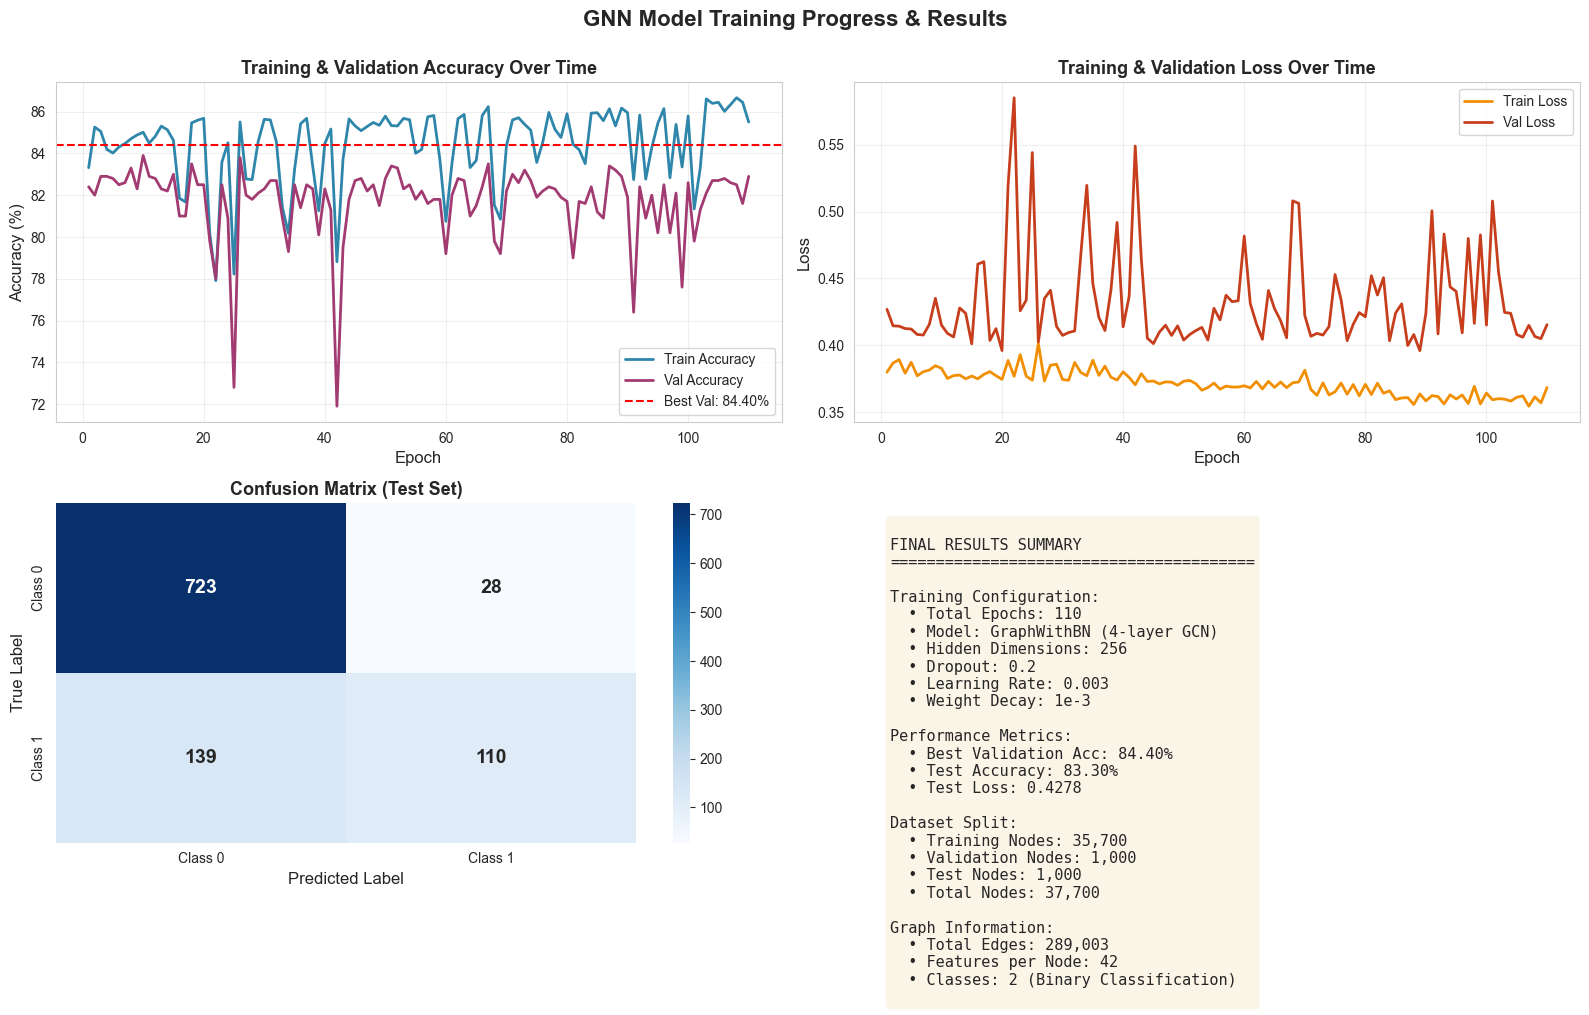


Training visualizations generated successfully!


In [262]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('GNN Model Training Progress & Results', fontsize=16, fontweight='bold', y=1.00)

# 1. Training and Validation Accuracy
ax1 = axes[0, 0]
epochs_range = range(1, len(train_accs) + 1)
ax1.plot(epochs_range, [acc * 100 for acc in train_accs], label='Train Accuracy', linewidth=2, color='#2E86AB')
ax1.plot(epochs_range, [acc * 100 for acc in val_accs], label='Val Accuracy', linewidth=2, color='#A23B72')
ax1.axhline(y=best_accuracy * 100, color='red', linestyle='--', linewidth=1.5, label=f'Best Val: {best_accuracy*100:.2f}%')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Training & Validation Accuracy Over Time', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Training and Validation Loss
ax2 = axes[0, 1]
ax2.plot(epochs_range, train_losses, label='Train Loss', linewidth=2, color='#F18F01')
ax2.plot(epochs_range, val_losses, label='Val Loss', linewidth=2, color='#C73E1D')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Training & Validation Loss Over Time', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Confusion Matrix Heatmap
ax3 = axes[1, 0]
cm = confusion_matrix(test_labels_cpu, test_pred_cpu)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax3, 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'],
            annot_kws={"size": 14, "weight": "bold"})
ax3.set_xlabel('Predicted Label', fontsize=12)
ax3.set_ylabel('True Label', fontsize=12)
ax3.set_title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')

# 4. Final Results Summary
ax4 = axes[1, 1]
ax4.axis('off')
results_text = f"""
FINAL RESULTS SUMMARY
{'=' * 40}

Training Configuration:
  • Total Epochs: {len(train_accs)}
  • Model: GraphWithBN (4-layer GCN)
  • Hidden Dimensions: 256
  • Dropout: 0.2
  • Learning Rate: 0.003
  • Weight Decay: 1e-3

Performance Metrics:
  • Best Validation Acc: {best_accuracy*100:.2f}%
  • Test Accuracy: {test_acc*100:.2f}%
  • Test Loss: {test_loss:.4f}

Dataset Split:
  • Training Nodes: {split.train_mask.sum().item():,}
  • Validation Nodes: {split.val_mask.sum().item():,}
  • Test Nodes: {split.test_mask.sum().item():,}
  • Total Nodes: {len(labels):,}

Graph Information:
  • Total Edges: {edges.shape[1]:,}
  • Features per Node: {features_tensor.shape[1]}
  • Classes: 2 (Binary Classification)
"""
ax4.text(0.05, 0.95, results_text, transform=ax4.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("\nTraining visualizations generated successfully!")

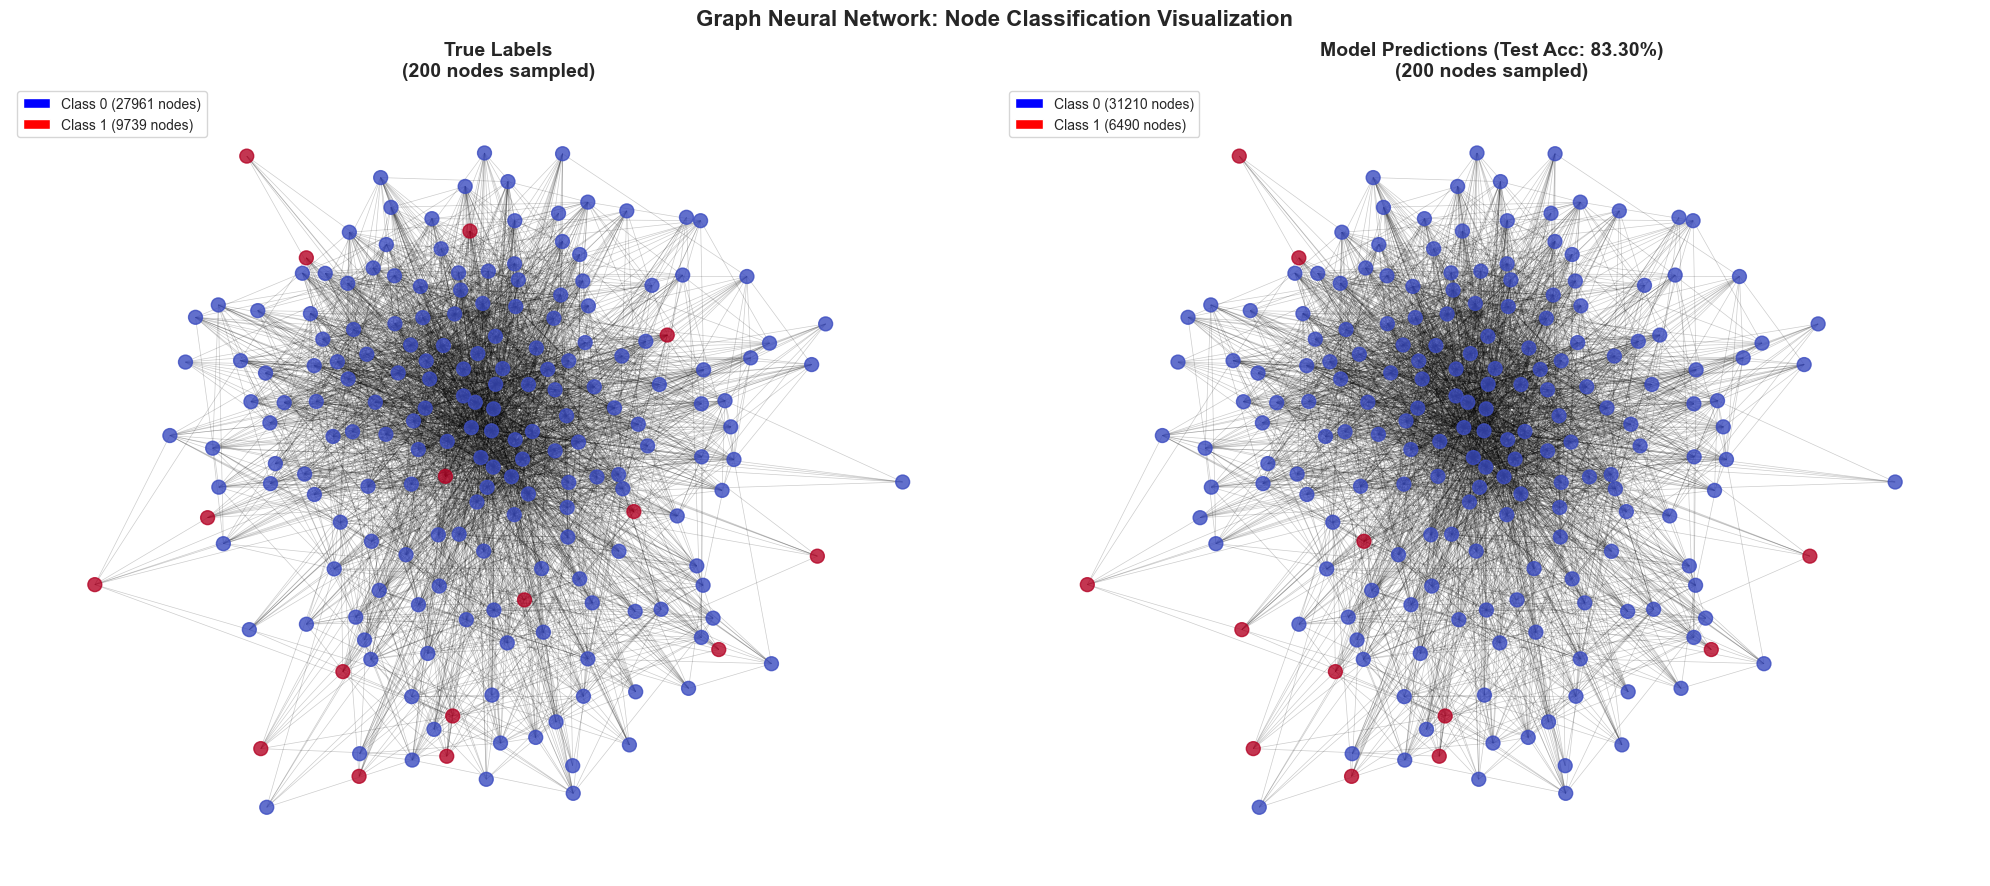


Graph Statistics:
   Total Nodes: 37,700
   Total Edges: 289,003
   Visualized Nodes: 200
   Accuracy on Visualized Subgraph: 96.00%


In [263]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Sample a subset of the graph for visualization (too large to visualize all nodes)
num_nodes_to_visualize = 200

# Create a NetworkX graph from edges
G = nx.Graph()
edges_np = edges.cpu().numpy()
edge_list = list(zip(edges_np[0], edges_np[1]))
G.add_edges_from(edge_list)

# Get a subgraph with connected nodes
# Select nodes with highest degree (most connected)
node_degrees = dict(G.degree())
top_nodes = sorted(node_degrees, key=node_degrees.get, reverse=True)[:num_nodes_to_visualize]
subgraph = G.subgraph(top_nodes)

# Get predictions for all nodes
model.eval()
with torch.no_grad():
    all_predictions = model(features_tensor, edges).argmax(dim=1).cpu().numpy()

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('Graph Neural Network: Node Classification Visualization', fontsize=16, fontweight='bold')

# Color mapping
true_labels_np = labels.cpu().numpy()
node_colors_true = [true_labels_np[node] for node in subgraph.nodes()]
node_colors_pred = [all_predictions[node] for node in subgraph.nodes()]

# Layout for visualization
pos = nx.spring_layout(subgraph, k=0.5, iterations=50, seed=42)

# Plot 1: True Labels
ax1 = axes[0]
nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors_true, 
                       node_size=100, cmap='coolwarm', alpha=0.8, ax=ax1)
nx.draw_networkx_edges(subgraph, pos, alpha=0.2, width=0.5, ax=ax1)
ax1.set_title(f'True Labels\n({len(subgraph.nodes())} nodes sampled)', 
              fontsize=14, fontweight='bold')
ax1.axis('off')

# Add legend for true labels
from matplotlib.patches import Patch
legend_elements_true = [
    Patch(facecolor='blue', label=f'Class 0 ({(true_labels_np==0).sum()} nodes)'),
    Patch(facecolor='red', label=f'Class 1 ({(true_labels_np==1).sum()} nodes)')
]
ax1.legend(handles=legend_elements_true, loc='upper left', fontsize=10)

# Plot 2: Predicted Labels
ax2 = axes[1]
nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors_pred, 
                       node_size=100, cmap='coolwarm', alpha=0.8, ax=ax2)
nx.draw_networkx_edges(subgraph, pos, alpha=0.2, width=0.5, ax=ax2)
ax2.set_title(f'Model Predictions (Test Acc: {test_acc*100:.2f}%)\n({len(subgraph.nodes())} nodes sampled)', 
              fontsize=14, fontweight='bold')
ax2.axis('off')

# Add legend for predictions
legend_elements_pred = [
    Patch(facecolor='blue', label=f'Class 0 ({(all_predictions==0).sum()} nodes)'),
    Patch(facecolor='red', label=f'Class 1 ({(all_predictions==1).sum()} nodes)')
]
ax2.legend(handles=legend_elements_pred, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# Calculate accuracy on the visualized subgraph
subgraph_nodes = list(subgraph.nodes())
subgraph_accuracy = (all_predictions[subgraph_nodes] == true_labels_np[subgraph_nodes]).mean()
print(f"\nGraph Statistics:")
print(f"   Total Nodes: {len(G.nodes):,}")
print(f"   Total Edges: {len(G.edges):,}")
print(f"   Visualized Nodes: {len(subgraph.nodes())}")
print(f"   Accuracy on Visualized Subgraph: {subgraph_accuracy*100:.2f}%")

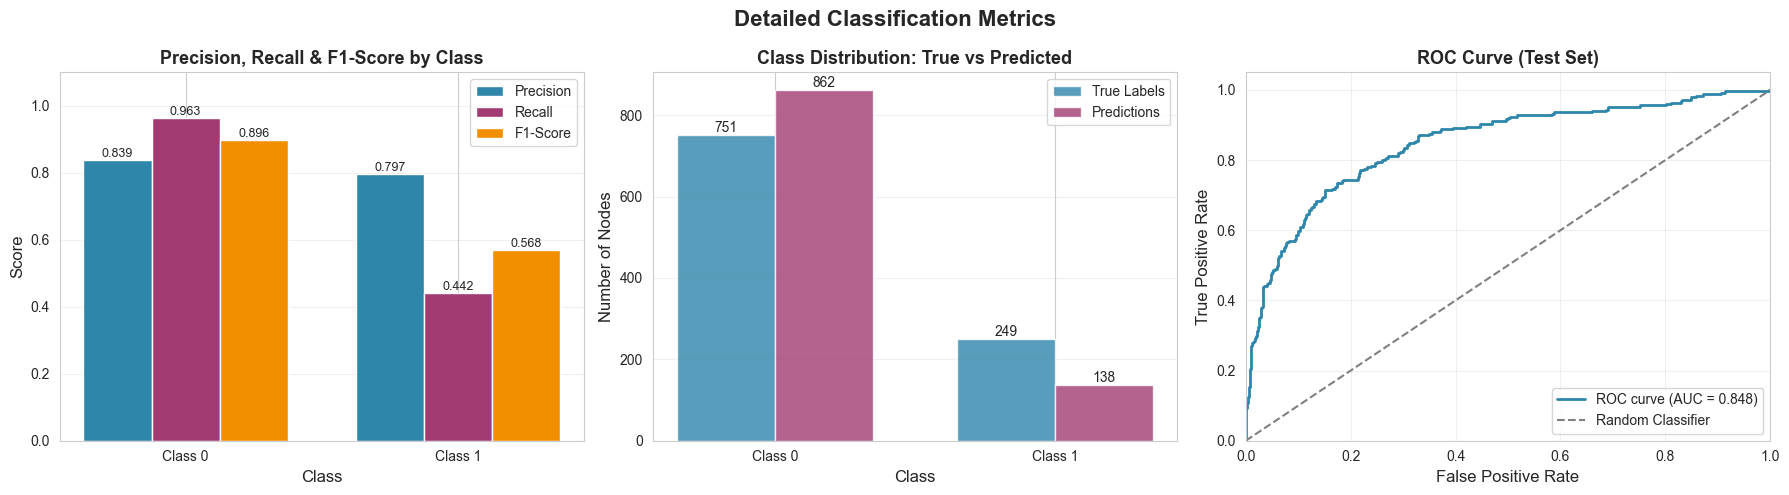


Detailed metrics visualization complete!
   AUC-ROC Score: 0.8477


In [264]:
# Classification Performance Metrics Visualization
from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Detailed Classification Metrics', fontsize=16, fontweight='bold')

# 1. Precision, Recall, F1-Score Bar Chart
ax1 = axes[0]
precision, recall, f1, _ = precision_recall_fscore_support(test_labels_cpu, test_pred_cpu, average=None)
x = np.arange(2)
width = 0.25

bars1 = ax1.bar(x - width, precision, width, label='Precision', color='#2E86AB')
bars2 = ax1.bar(x, recall, width, label='Recall', color='#A23B72')
bars3 = ax1.bar(x + width, f1, width, label='F1-Score', color='#F18F01')

ax1.set_xlabel('Class', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Precision, Recall & F1-Score by Class', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['Class 0', 'Class 1'])
ax1.legend(fontsize=10)
ax1.set_ylim([0, 1.1])
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Class Distribution (True vs Predicted)
ax2 = axes[1]
true_counts = np.bincount(test_labels_cpu)
pred_counts = np.bincount(test_pred_cpu)
x = np.arange(2)
width = 0.35

bars1 = ax2.bar(x - width/2, true_counts, width, label='True Labels', color='#2E86AB', alpha=0.8)
bars2 = ax2.bar(x + width/2, pred_counts, width, label='Predictions', color='#A23B72', alpha=0.8)

ax2.set_xlabel('Class', fontsize=12)
ax2.set_ylabel('Number of Nodes', fontsize=12)
ax2.set_title('Class Distribution: True vs Predicted', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['Class 0', 'Class 1'])
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=10)

# 3. ROC Curve
ax3 = axes[2]
# Get probability predictions for ROC curve
with torch.no_grad():
    probs = torch.softmax(model(features_tensor, edges)[split.test_mask], dim=1)
    probs_class1 = probs[:, 1].cpu().numpy()

fpr, tpr, _ = roc_curve(test_labels_cpu, probs_class1)
roc_auc = auc(fpr, tpr)

ax3.plot(fpr, tpr, color='#2E86AB', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax3.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random Classifier')
ax3.set_xlabel('False Positive Rate', fontsize=12)
ax3.set_ylabel('True Positive Rate', fontsize=12)
ax3.set_title('ROC Curve (Test Set)', fontsize=13, fontweight='bold')
ax3.legend(loc='lower right', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

print(f"\nDetailed metrics visualization complete!")
print(f"   AUC-ROC Score: {roc_auc:.4f}")